# DR9 local overdensity: sweep-file accumulation

This notebook is the RAM-safe sweep version of the DR9 local-overdensity calculation. It can still run one-file diagnostics, but its main production section iterates through DR9 sweep files one at a time, accumulates galaxy counts and sweep-footprint coverage, and computes a local-background-subtracted overdensity around redMaPPer clusters.

In [1]:
# Configuration: edit these values if needed, then run the notebook top to bottom.

from pathlib import Path
import sys

# On NERSC this should make your repo-level setup.py importable.
REPO_DIR = Path('/global/homes/z/zzhang13/DESI')
if REPO_DIR.exists() and str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

try:
    from setup import data_dir
    CATALOG_PATH = Path(data_dir()) / 'bgs_clus_RM_gal_matched.pickle'
except Exception:
    CATALOG_PATH = Path('/global/homes/z/zzhang13/DESI/data/bgs_clus_RM_gal_matched.pickle')

SWEEP_FILE = Path('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/sweep/9.0/sweep-130p050-140p055.fits')
SWEEP_DIR = SWEEP_FILE.parent
SWEEP_PATTERN = 'sweep-*.fits'
MAX_SWEEP_FILES = None   # set to e.g. 5 for a quick test
SAVE_EVERY_N_FILES = 10
RANDOM_FILE = Path('/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/randoms-10-0.fits')

OUTPUT_DIR = Path('dr9_one_file_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RMIN_HMPC = 1.5
RMAX_HMPC = 8.0        # signal annulus: cluster environment
BG_RMIN_HMPC = 12.0    # local background annulus
BG_RMAX_HMPC = 20.0
COVERAGE_MIN = 0.8     # require this coverage in both signal and background annuli
R_MAG_LIMIT = 23.5

NSIDE_GAL = 4096
NSIDE_RAND = 1024
NSIDE_RAND_AREA = 128
NSIDE_SWEEP_COVERAGE = 1024

print('Catalog:', CATALOG_PATH)
print('Sweep file:', SWEEP_FILE)
print('Random file:', RANDOM_FILE)
print('Output dir:', OUTPUT_DIR.resolve())

Catalog: /global/homes/z/zzhang13/DESI/catalogs/bgs_clus_RM_gal_matched.pickle
Sweep file: /global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/sweep/9.0/sweep-130p050-140p055.fits
Random file: /global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/randoms-10-0.fits
Output dir: /global/u1/z/zzhang13/DESI/local_overdensity/dr9_one_file_outputs


In [2]:
import gc
import pickle
from glob import glob

import astropy.units as u
from astropy.cosmology import Planck18
from astropy.table import Table, unique
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic, pearsonr, spearmanr

plt.rcParams.update({
    'figure.constrained_layout.use': True,
    'font.size': 13,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})

## Helper functions

In [3]:
def nanomaggies_to_mag(flux):
    flux = np.asarray(flux, dtype=float)
    mag = np.full(flux.shape, np.nan, dtype=float)
    good = np.isfinite(flux) & (flux > 0)
    mag[good] = 22.5 - 2.5 * np.log10(flux[good])
    return mag


def dereddened_mag(table, band):
    band = band.upper()
    flux = np.asarray(table[f'FLUX_{band}'], dtype=float)
    transmission = np.asarray(table[f'MW_TRANSMISSION_{band}'], dtype=float)
    return nanomaggies_to_mag(flux / transmission)


def dr9_galaxy_mask(table, r_mag_limit=23.5):
    mask = np.isfinite(table['RA']) & np.isfinite(table['DEC'])
    if 'TYPE' in table.colnames:
        mask &= np.asarray(table['TYPE']) != 'PSF'
    for band in ('G', 'R', 'Z'):
        col = f'FLUX_IVAR_{band}'
        if col in table.colnames:
            mask &= np.asarray(table[col], dtype=float) > 0
    if r_mag_limit is not None:
        r_dered = dereddened_mag(table, 'R')
        mask &= np.isfinite(r_dered) & (r_dered < r_mag_limit)
    return np.asarray(mask, dtype=bool)


def read_one_dr9_sweep(filename, r_mag_limit=23.5):
    table = Table.read(filename, hdu=1, memmap=True)
    mask = dr9_galaxy_mask(table, r_mag_limit=r_mag_limit)
    out = table[mask][['RA', 'DEC', 'TYPE']].copy()
    out['r_dered'] = dereddened_mag(table[mask], 'R')
    return out


def read_random_positions(filename):
    randoms = Table.read(filename, hdu=1, memmap=True)
    ra = np.asarray(randoms['RA'], dtype=float)
    dec = np.asarray(randoms['DEC'], dtype=float)
    good = np.isfinite(ra) & np.isfinite(dec)
    return ra[good], dec[good]

def read_sweep_bounds(filename):
    table = Table.read(filename, hdu=1, memmap=True)
    ra = np.asarray(table['RA'], dtype=float)
    dec = np.asarray(table['DEC'], dtype=float)
    good = np.isfinite(ra) & np.isfinite(dec)
    return {
        'ra_min': np.nanmin(ra[good]),
        'ra_max': np.nanmax(ra[good]),
        'dec_min': np.nanmin(dec[good]),
        'dec_max': np.nanmax(dec[good]),
    }


def inside_ra_dec_box(ra, dec, bounds):
    ra = np.asarray(ra, dtype=float)
    dec = np.asarray(dec, dtype=float)
    return (
        (ra >= bounds['ra_min'])
        & (ra <= bounds['ra_max'])
        & (dec >= bounds['dec_min'])
        & (dec <= bounds['dec_max'])
    )


In [4]:
def radec_to_unitvec(ra_deg, dec_deg):
    ra = np.deg2rad(np.asarray(ra_deg, dtype=float))
    dec = np.deg2rad(np.asarray(dec_deg, dtype=float))
    cosd = np.cos(dec)
    return np.column_stack((cosd * np.cos(ra), cosd * np.sin(ra), np.sin(dec)))


def annulus_theta_radians(z, Rmin_hMpc=1.5, Rmax_hMpc=10.0, cosmo=Planck18):
    h = cosmo.h
    Rmin_Mpc = (Rmin_hMpc / h) * u.Mpc
    Rmax_Mpc = (Rmax_hMpc / h) * u.Mpc
    Dm = cosmo.comoving_transverse_distance(z)
    th_min = (Rmin_Mpc / Dm).decompose().value
    th_max = (Rmax_Mpc / Dm).decompose().value
    return th_min, th_max


def spherical_annulus_area_sr(theta_min, theta_max):
    return 2.0 * np.pi * (np.cos(theta_min) - np.cos(theta_max))


def build_galaxy_healpix_index(ra_gal, dec_gal, nside=4096, nest=False):
    theta = np.deg2rad(90.0 - np.asarray(dec_gal, dtype=float))
    phi = np.deg2rad(np.asarray(ra_gal, dtype=float))
    pix = hp.ang2pix(nside, theta, phi, nest=nest)
    order = np.argsort(pix)
    pix_sorted = pix[order]
    uniq_pix, start = np.unique(pix_sorted, return_index=True)
    end = np.r_[start[1:], len(pix_sorted)]
    return {'nside': nside, 'nest': nest, 'order': order, 'uniq_pix': uniq_pix, 'start': start, 'end': end}


def gather_candidates(index, pix_list):
    uniq_pix = index['uniq_pix']
    pix_list = np.asarray(pix_list, dtype=uniq_pix.dtype)
    pos = np.searchsorted(uniq_pix, pix_list)
    inside = pos < len(uniq_pix)
    pos_valid = pos[inside]
    pix_valid = pix_list[inside]
    good = uniq_pix[pos_valid] == pix_valid
    pos = pos_valid[good]
    if len(pos) == 0:
        return np.empty(0, dtype=np.int64)
    order = index['order']
    start = index['start']
    end = index['end']
    return np.concatenate([order[start[p]:end[p]] for p in pos])

In [5]:
def count_galaxies_in_annuli(
    ra_cl,
    dec_cl,
    z_cl,
    ra_gal,
    dec_gal,
    Rmin_hMpc=1.5,
    Rmax_hMpc=10.0,
    nside=4096,
    nest=False,
    verbose_every=500,
):
    ra_cl = np.asarray(ra_cl, dtype=float)
    dec_cl = np.asarray(dec_cl, dtype=float)
    z_cl = np.asarray(z_cl, dtype=float)
    gal_vecs = radec_to_unitvec(ra_gal, dec_gal)
    cl_vecs = radec_to_unitvec(ra_cl, dec_cl)
    index = build_galaxy_healpix_index(ra_gal, dec_gal, nside=nside, nest=nest)

    counts = np.zeros(len(ra_cl), dtype=np.int64)
    area_sr = np.full(len(ra_cl), np.nan, dtype=float)

    for i, (vec, z) in enumerate(zip(cl_vecs, z_cl)):
        if verbose_every and (i + 1) % verbose_every == 0:
            print(f'  counted {i + 1:,}/{len(ra_cl):,} clusters')

        if not np.isfinite(z) or z <= 0:
            continue

        th_min, th_max = annulus_theta_radians(z, Rmin_hMpc=Rmin_hMpc, Rmax_hMpc=Rmax_hMpc)
        area_sr[i] = spherical_annulus_area_sr(th_min, th_max)

        pix_outer = hp.query_disc(nside, vec, th_max, inclusive=True, nest=nest)
        cand = gather_candidates(index, pix_outer)
        if len(cand) == 0:
            continue

        dot = np.clip(gal_vecs[cand] @ vec, -1.0, 1.0)
        sep = np.arccos(dot)
        counts[i] = np.count_nonzero((sep >= th_min) & (sep < th_max))

    return counts, area_sr


def estimate_random_surface_density(ra_rand, dec_rand, nside_area=128):
    theta = np.deg2rad(90.0 - dec_rand)
    phi = np.deg2rad(ra_rand)
    pix = hp.ang2pix(nside_area, theta, phi)
    n_occ = len(np.unique(pix))
    area_sr = n_occ * hp.nside2pixarea(nside_area)
    area_deg2 = area_sr * (180.0 / np.pi) ** 2
    nbar_sr = len(ra_rand) / area_sr
    nbar_deg2 = len(ra_rand) / area_deg2
    return nbar_sr, nbar_deg2, area_sr, area_deg2

def sweep_annulus_coverage_for_clusters(
    ra_cl,
    dec_cl,
    z_cl,
    sweep_bounds,
    Rmin_hMpc=1.5,
    Rmax_hMpc=8.0,
    nside=1024,
    nest=False,
    verbose_every=500,
):
    """Estimate the fraction of each cluster annulus inside the one sweep file.

    The annulus is represented by equal-area HEALPix pixels. Coverage is the
    fraction of annulus-pixel centers whose RA/Dec lies inside the sweep file
    RA/Dec bounds. This is the relevant one-file footprint cut; it is not a
    DESI random-catalog footprint cut.
    """

    ra_cl = np.asarray(ra_cl, dtype=float)
    dec_cl = np.asarray(dec_cl, dtype=float)
    z_cl = np.asarray(z_cl, dtype=float)
    cl_vecs = radec_to_unitvec(ra_cl, dec_cl)
    coverage = np.full(len(ra_cl), np.nan, dtype=float)
    n_pix_annulus = np.zeros(len(ra_cl), dtype=int)

    for i, (vec, z) in enumerate(zip(cl_vecs, z_cl)):
        if verbose_every and (i + 1) % verbose_every == 0:
            print(f'  coverage {i + 1:,}/{len(ra_cl):,} clusters')

        if not np.isfinite(z) or z <= 0:
            continue

        th_min, th_max = annulus_theta_radians(z, Rmin_hMpc=Rmin_hMpc, Rmax_hMpc=Rmax_hMpc)
        pix_out = hp.query_disc(nside, vec, th_max, inclusive=True, nest=nest)
        pix_in = hp.query_disc(nside, vec, th_min, inclusive=True, nest=nest)
        pix_ann = np.setdiff1d(pix_out, pix_in, assume_unique=False)
        n_pix_annulus[i] = len(pix_ann)

        if len(pix_ann) == 0:
            continue

        theta_pix, phi_pix = hp.pix2ang(nside, pix_ann, nest=nest)
        ra_pix = np.rad2deg(phi_pix)
        dec_pix = 90.0 - np.rad2deg(theta_pix)
        inside = inside_ra_dec_box(ra_pix, dec_pix, sweep_bounds)
        coverage[i] = np.count_nonzero(inside) / len(pix_ann)

    return coverage, n_pix_annulus


## Load clusters, one sweep file, and one random file

In [6]:
with CATALOG_PATH.open('rb') as handle:
    bgs_matched = pickle.load(handle)

rm_tab = unique(bgs_matched, keys='ID')
print(f'Clusters: {len(rm_tab):,}')

sweep_bounds = read_sweep_bounds(SWEEP_FILE)
print('Sweep bounds:', sweep_bounds)

dr9_gal = read_one_dr9_sweep(SWEEP_FILE, r_mag_limit=R_MAG_LIMIT)
print(f'DR9 galaxies kept from one sweep file: {len(dr9_gal):,}')

rand_ra, rand_dec = read_random_positions(RANDOM_FILE)
print(f'Random points from one random file: {len(rand_ra):,}')

Clusters: 6,739
Sweep bounds: {'ra_min': 130.00000414607914, 'ra_max': 139.99997817332036, 'dec_min': 50.000001334138354, 'dec_max': 54.99999874572179}
DR9 galaxies kept from one sweep file: 1,285,012
Random points from one random file: 51,736,940


## Cluster and sweep-file overlap

This plot checks the basic one-file sanity condition: clusters outside the sweep-file RA/Dec range should not be expected to have DR9 galaxies counted around them.

Cluster centers inside sweep RA/Dec box: 16/6,739


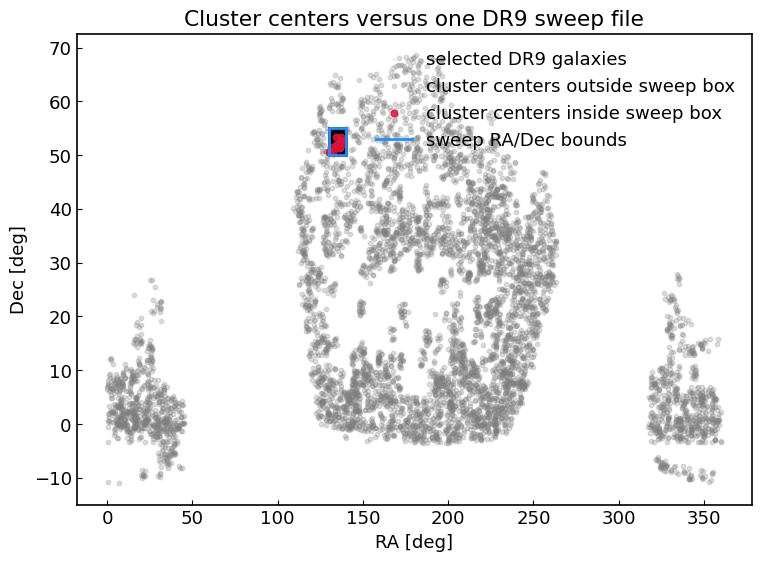

In [7]:
cluster_ra = np.asarray(rm_tab['RA_x'], dtype=float)
cluster_dec = np.asarray(rm_tab['DEC_x'], dtype=float)
cluster_in_sweep_box = inside_ra_dec_box(cluster_ra, cluster_dec, sweep_bounds)
print(f'Cluster centers inside sweep RA/Dec box: {np.count_nonzero(cluster_in_sweep_box):,}/{len(rm_tab):,}')

rng = np.random.default_rng(123)
max_gal_plot = 100_000
gal_plot_idx = np.arange(len(dr9_gal))
if len(gal_plot_idx) > max_gal_plot:
    gal_plot_idx = rng.choice(gal_plot_idx, size=max_gal_plot, replace=False)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(dr9_gal['RA'][gal_plot_idx], dr9_gal['DEC'][gal_plot_idx], s=1, alpha=0.08, color='black', label='selected DR9 galaxies')
ax.scatter(cluster_ra[~cluster_in_sweep_box], cluster_dec[~cluster_in_sweep_box], s=10, alpha=0.25, color='tab:gray', label='cluster centers outside sweep box')
ax.scatter(cluster_ra[cluster_in_sweep_box], cluster_dec[cluster_in_sweep_box], s=22, alpha=0.85, color='crimson', label='cluster centers inside sweep box')

rect_ra = [sweep_bounds['ra_min'], sweep_bounds['ra_max'], sweep_bounds['ra_max'], sweep_bounds['ra_min'], sweep_bounds['ra_min']]
rect_dec = [sweep_bounds['dec_min'], sweep_bounds['dec_min'], sweep_bounds['dec_max'], sweep_bounds['dec_max'], sweep_bounds['dec_min']]
ax.plot(rect_ra, rect_dec, color='dodgerblue', lw=2, label='sweep RA/Dec bounds')

ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title('Cluster centers versus one DR9 sweep file')
ax.legend(frameon=False, loc='best')
fig.savefig(OUTPUT_DIR / 'dr9_one_file_cluster_sweep_overlap.png', dpi=180)
plt.show()

## Sweep-file galaxy density diagnostic

This maps the selected DR9 galaxies in the one sweep file into HEALPix pixels. The map and histogram show whether the selected photometric density is spatially uniform or patchy across the file.

HEALPix NSIDE: 256
Pixel area: 0.05246 deg^2
Occupied pixels: 652
DR9 selected-galaxy density in occupied pixels [gal/deg^2]:
  q01=1.28e+03, q05=4.22e+03, q16=3.38e+04, median=4.12e+04, q84=4.55e+04, q95=4.83e+04, q99=5.06e+04
  q84/q16 = 1.35


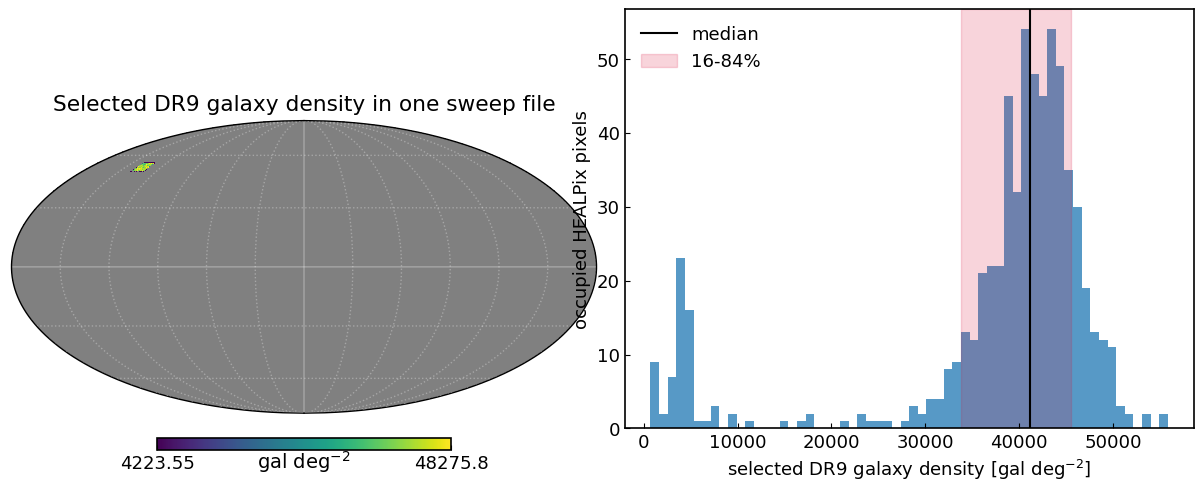

In [8]:
def make_healpix_density_map(ra, dec, nside=256, nest=False):
    ra = np.asarray(ra, dtype=float)
    dec = np.asarray(dec, dtype=float)
    good = np.isfinite(ra) & np.isfinite(dec)
    theta = np.deg2rad(90.0 - dec[good])
    phi = np.deg2rad(ra[good])
    pix = hp.ang2pix(nside, theta, phi, nest=nest)
    counts = np.bincount(pix, minlength=hp.nside2npix(nside)).astype(float)
    pix_area_deg2 = hp.nside2pixarea(nside, degrees=True)
    density = counts / pix_area_deg2
    occupied = counts > 0
    density_map = density.copy()
    density_map[~occupied] = hp.UNSEEN
    return density_map, density[occupied], counts[occupied], pix_area_deg2


NSIDE_SWEEP_DENSITY = 256
density_map, occupied_density, occupied_counts, pix_area_deg2 = make_healpix_density_map(
    dr9_gal['RA'],
    dr9_gal['DEC'],
    nside=NSIDE_SWEEP_DENSITY,
)

q = np.percentile(occupied_density, [1, 5, 16, 50, 84, 95, 99])
print(f'HEALPix NSIDE: {NSIDE_SWEEP_DENSITY}')
print(f'Pixel area: {pix_area_deg2:.5f} deg^2')
print(f'Occupied pixels: {len(occupied_density):,}')
print('DR9 selected-galaxy density in occupied pixels [gal/deg^2]:')
print(f'  q01={q[0]:.3g}, q05={q[1]:.3g}, q16={q[2]:.3g}, median={q[3]:.3g}, q84={q[4]:.3g}, q95={q[5]:.3g}, q99={q[6]:.3g}')
print(f'  q84/q16 = {q[4] / q[2]:.3g}')

fig = plt.figure(figsize=(12, 4.8))
hp.mollview(
    density_map,
    fig=fig.number,
    sub=(1, 2, 1),
    title='Selected DR9 galaxy density in one sweep file',
    unit=r'gal deg$^{-2}$',
    cmap='viridis',
    min=q[1],
    max=q[5],
)
hp.graticule(color='white', alpha=0.3)

ax = fig.add_subplot(1, 2, 2)
ax.hist(occupied_density, bins=60, histtype='stepfilled', alpha=0.75)
ax.axvline(q[3], color='black', lw=1.5, label='median')
ax.axvspan(q[2], q[4], color='crimson', alpha=0.18, label='16-84%')
ax.set_xlabel(r'selected DR9 galaxy density [gal deg$^{-2}$]')
ax.set_ylabel('occupied HEALPix pixels')
ax.legend(frameon=False)
fig.savefig(OUTPUT_DIR / 'dr9_one_file_sweep_density_map.png', dpi=180)
plt.show()

## Mollweide cluster/density overlap

This plots the selected DR9 sweep-file density map in Mollweide projection and overlays the cluster positions. Clusters outside the colored density patch are outside this one sweep file and should have zero DR9 counts.

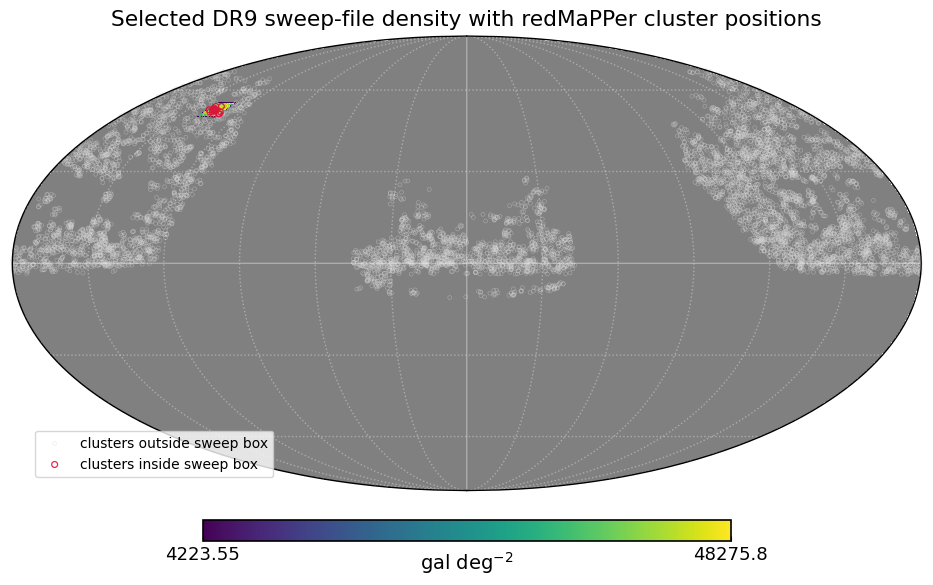

Cluster centers inside sweep RA/Dec box: 16/6,739
Saved: dr9_one_file_outputs/dr9_one_file_mollview_density_clusters.png


In [9]:
# Mollweide density map with cluster positions overlaid.
# Requires the previous density-map cell to have created density_map and q.

cluster_ra = np.asarray(rm_tab['RA_x'], dtype=float)
cluster_dec = np.asarray(rm_tab['DEC_x'], dtype=float)
cluster_in_sweep_box = inside_ra_dec_box(cluster_ra, cluster_dec, sweep_bounds)

fig = plt.figure(figsize=(11, 6))
hp.mollview(
    density_map,
    fig=fig.number,
    title='Selected DR9 sweep-file density with redMaPPer cluster positions',
    unit=r'gal deg$^{-2}$',
    cmap='viridis',
    min=q[1],
    max=q[5],
)
hp.graticule(color='white', alpha=0.35)

# hp.projscatter expects lon/lat in degrees when lonlat=True.
hp.projscatter(
    cluster_ra[~cluster_in_sweep_box],
    cluster_dec[~cluster_in_sweep_box],
    lonlat=True,
    s=8,
    marker='o',
    facecolors='none',
    edgecolors='lightgray',
    linewidths=0.45,
    alpha=0.45,
    label='clusters outside sweep box',
)
hp.projscatter(
    cluster_ra[cluster_in_sweep_box],
    cluster_dec[cluster_in_sweep_box],
    lonlat=True,
    s=18,
    marker='o',
    facecolors='none',
    edgecolors='crimson',
    linewidths=0.9,
    alpha=0.9,
    label='clusters inside sweep box',
)

ax = plt.gca()
ax.legend(loc='lower left', bbox_to_anchor=(0.02, 0.02), frameon=True, fontsize=10)
fig.savefig(OUTPUT_DIR / 'dr9_one_file_mollview_density_clusters.png', dpi=180)
plt.show()

print(f'Cluster centers inside sweep RA/Dec box: {np.count_nonzero(cluster_in_sweep_box):,}/{len(rm_tab):,}')
print('Saved:', OUTPUT_DIR / 'dr9_one_file_mollview_density_clusters.png')

## Estimate mean random density

This follows the old notebook's one-random-file estimate: build an occupied-pixel footprint and divide the number of random points by that area.

In [10]:
nrandbar_sr, nrandbar_deg2, rand_area_sr, rand_area_deg2 = estimate_random_surface_density(
    rand_ra,
    rand_dec,
    nside_area=NSIDE_RAND_AREA,
)

print(f'Occupied random area: {rand_area_deg2:.1f} deg^2')
print(f'Mean random density: {nrandbar_deg2:.4g} deg^-2')

Occupied random area: 21067.5 deg^2
Mean random density: 2456 deg^-2


## Count DR9 galaxies in signal/background annuli

Randoms are no longer used for the main coverage flag. The coverage flag below is estimated from the overlap between each annulus and the sweep-file footprint.

In [11]:
print('Counting DR9 galaxies in the signal annulus...')
Ngal_signal, area_signal_sr = count_galaxies_in_annuli(
    rm_tab['RA_x'],
    rm_tab['DEC_x'],
    rm_tab['Z_SPEC_x'],
    dr9_gal['RA'],
    dr9_gal['DEC'],
    Rmin_hMpc=RMIN_HMPC,
    Rmax_hMpc=RMAX_HMPC,
    nside=NSIDE_GAL,
    verbose_every=500,
)

print('Counting DR9 galaxies in the local background annulus...')
Ngal_bg, area_bg_sr = count_galaxies_in_annuli(
    rm_tab['RA_x'],
    rm_tab['DEC_x'],
    rm_tab['Z_SPEC_x'],
    dr9_gal['RA'],
    dr9_gal['DEC'],
    Rmin_hMpc=BG_RMIN_HMPC,
    Rmax_hMpc=BG_RMAX_HMPC,
    nside=NSIDE_GAL,
    verbose_every=500,
)

print('Estimating signal-annulus coverage from the sweep-file footprint...')
coverage_signal, n_pix_signal_coverage = sweep_annulus_coverage_for_clusters(
    rm_tab['RA_x'],
    rm_tab['DEC_x'],
    rm_tab['Z_SPEC_x'],
    sweep_bounds,
    Rmin_hMpc=RMIN_HMPC,
    Rmax_hMpc=RMAX_HMPC,
    nside=NSIDE_SWEEP_COVERAGE,
    verbose_every=500,
)

print('Estimating background-annulus coverage from the sweep-file footprint...')
coverage_bg, n_pix_bg_coverage = sweep_annulus_coverage_for_clusters(
    rm_tab['RA_x'],
    rm_tab['DEC_x'],
    rm_tab['Z_SPEC_x'],
    sweep_bounds,
    Rmin_hMpc=BG_RMIN_HMPC,
    Rmax_hMpc=BG_RMAX_HMPC,
    nside=NSIDE_SWEEP_COVERAGE,
    verbose_every=500,
)


Counting DR9 galaxies in the signal annulus...
  counted 500/6,739 clusters
  counted 1,000/6,739 clusters
  counted 1,500/6,739 clusters
  counted 2,000/6,739 clusters
  counted 2,500/6,739 clusters
  counted 3,000/6,739 clusters
  counted 3,500/6,739 clusters
  counted 4,000/6,739 clusters
  counted 4,500/6,739 clusters
  counted 5,000/6,739 clusters
  counted 5,500/6,739 clusters
  counted 6,000/6,739 clusters
  counted 6,500/6,739 clusters
Counting DR9 galaxies in the local background annulus...
  counted 500/6,739 clusters
  counted 1,000/6,739 clusters
  counted 1,500/6,739 clusters
  counted 2,000/6,739 clusters
  counted 2,500/6,739 clusters
  counted 3,000/6,739 clusters
  counted 3,500/6,739 clusters
  counted 4,000/6,739 clusters
  counted 4,500/6,739 clusters
  counted 5,000/6,739 clusters
  counted 5,500/6,739 clusters
  counted 6,000/6,739 clusters
  counted 6,500/6,739 clusters
Estimating signal-annulus coverage from the sweep-file footprint...
  coverage 500/6,739 clust

## Build the overdensity table

In [12]:
area_signal_deg2 = area_signal_sr * (180.0 / np.pi) ** 2
area_bg_deg2 = area_bg_sr * (180.0 / np.pi) ** 2

# Diagnostic global-background estimate. This is not the preferred estimator,
# but it is kept so we can compare against the older notebook-style subtraction.
Nrand_signal_exp = nrandbar_deg2 * area_signal_deg2
Sigma_signal_raw = Ngal_signal / area_signal_deg2
Sigma_excess_global = Sigma_signal_raw - nrandbar_deg2
Nexcess_global = Ngal_signal - Nrand_signal_exp

# Preferred local-background estimator. Here coverage means the fraction of the
# physical annulus that lies inside this one sweep file's RA/Dec footprint.
area_signal_eff = area_signal_deg2 * coverage_signal
area_bg_eff = area_bg_deg2 * coverage_bg

Sigma_signal_covcorr = Ngal_signal / area_signal_eff
Sigma_bg_covcorr = Ngal_bg / area_bg_eff
Sigma_excess_local = Sigma_signal_covcorr - Sigma_bg_covcorr
Nexcess_local = Sigma_excess_local * area_signal_deg2

rm_overdensity = rm_tab.copy()
rm_overdensity['Ngal_signal_DR9_annulus'] = Ngal_signal
rm_overdensity['Ngal_bg_DR9_annulus'] = Ngal_bg
rm_overdensity['area_signal_deg2'] = area_signal_deg2
rm_overdensity['area_bg_deg2'] = area_bg_deg2
rm_overdensity['coverage_signal_sweep'] = coverage_signal
rm_overdensity['coverage_bg_sweep'] = coverage_bg
rm_overdensity['n_pix_signal_coverage'] = n_pix_signal_coverage
rm_overdensity['n_pix_bg_coverage'] = n_pix_bg_coverage
rm_overdensity['Nrand_signal_exp_global'] = Nrand_signal_exp
rm_overdensity['Sigma_signal_covcorr'] = Sigma_signal_covcorr
rm_overdensity['Sigma_bg_covcorr'] = Sigma_bg_covcorr
rm_overdensity['Sigma_excess_global_DR9_annulus'] = Sigma_excess_global
rm_overdensity['Nexcess_global_DR9_annulus'] = Nexcess_global
rm_overdensity['Sigma_excess_local_DR9_annulus'] = Sigma_excess_local
rm_overdensity['Nexcess_local_DR9_annulus'] = Nexcess_local

coverage_mask = (
    (np.asarray(rm_overdensity['coverage_signal_sweep'], dtype=float) > COVERAGE_MIN)
    & (np.asarray(rm_overdensity['coverage_bg_sweep'], dtype=float) > COVERAGE_MIN)
)
finite_mask = (
    np.isfinite(rm_overdensity['Nexcess_local_DR9_annulus'])
    & np.isfinite(rm_overdensity['Sigma_excess_local_DR9_annulus'])
)

rm_filt = rm_overdensity[coverage_mask & finite_mask]

print(f'Coverage cut: signal and background sweep coverage > {COVERAGE_MIN}')
print(f'Kept {len(rm_filt):,}/{len(rm_overdensity):,} clusters')
print(f"Clusters with Ngal_signal > 0 before coverage cut: {np.count_nonzero(np.asarray(rm_overdensity['Ngal_signal_DR9_annulus']) > 0):,}")
print(f"Clusters with Ngal_signal > 0 after coverage cut: {np.count_nonzero(np.asarray(rm_filt['Ngal_signal_DR9_annulus']) > 0):,}")

rm_overdensity.write(OUTPUT_DIR / 'dr9_one_file_cluster_counts.ecsv', format='ascii.ecsv', overwrite=True)
rm_filt.write(OUTPUT_DIR / 'dr9_one_file_cluster_counts_coverage_cut.ecsv', format='ascii.ecsv', overwrite=True)


Coverage cut: signal and background sweep coverage > 0.8
Kept 9/6,739 clusters
Clusters with Ngal_signal > 0 before coverage cut: 21
Clusters with Ngal_signal > 0 after coverage cut: 9


## Quick diagnostics

In [13]:
def describe(name, arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    q = np.percentile(arr, [5, 16, 50, 84, 95]) if len(arr) else np.full(5, np.nan)
    print(f'\n{name}')
    print(f'  N      = {len(arr):,}')
    print(f'  mean   = {np.nanmean(arr):.4g}')
    print(f'  std    = {np.nanstd(arr):.4g}')
    print(f'  q05    = {q[0]:.4g}')
    print(f'  q16    = {q[1]:.4g}')
    print(f'  median = {q[2]:.4g}')
    print(f'  q84    = {q[3]:.4g}')
    print(f'  q95    = {q[4]:.4g}')


describe('coverage_signal_sweep', rm_overdensity['coverage_signal_sweep'])
describe('coverage_bg_sweep', rm_overdensity['coverage_bg_sweep'])
describe('Ngal_signal_DR9_annulus', rm_filt['Ngal_signal_DR9_annulus'])
describe('Ngal_bg_DR9_annulus', rm_filt['Ngal_bg_DR9_annulus'])
describe('Nexcess_global_DR9_annulus', rm_filt['Nexcess_global_DR9_annulus'])
describe('Nexcess_local_DR9_annulus', rm_filt['Nexcess_local_DR9_annulus'])
describe('Sigma_excess_local_DR9_annulus', rm_filt['Sigma_excess_local_DR9_annulus'])


coverage_signal_sweep
  N      = 6,739
  mean   = 0.002282
  std    = 0.04606
  q05    = 0
  q16    = 0
  median = 0
  q84    = 0
  q95    = 0

coverage_bg_sweep
  N      = 6,739
  mean   = 0.002166
  std    = 0.03925
  q05    = 0
  q16    = 0
  median = 0
  q84    = 0
  q95    = 0

Ngal_signal_DR9_annulus
  N      = 9
  mean   = 5.605e+04
  std    = 3.636e+04
  q05    = 2.414e+04
  q16    = 2.693e+04
  median = 4.18e+04
  q84    = 7.787e+04
  q95    = 1.184e+05

Ngal_bg_DR9_annulus
  N      = 9
  mean   = 2.096e+05
  std    = 1.179e+05
  q05    = 9.745e+04
  q16    = 1.115e+05
  median = 1.637e+05
  q84    = 2.882e+05
  q95    = 4.118e+05

Nexcess_global_DR9_annulus
  N      = 9
  mean   = 5.291e+04
  std    = 3.434e+04
  q05    = 2.278e+04
  q16    = 2.54e+04
  median = 3.948e+04
  q84    = 7.355e+04
  q95    = 1.118e+05

Nexcess_local_DR9_annulus
  N      = 9
  mean   = 1173
  std    = 1166
  q05    = -706.8
  q16    = 441.8
  median = 1147
  q84    = 2375
  q95    = 2544

Sigma_ex

In [14]:
def print_correlation(label, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(mask) < 3:
        print(f'{label}: not enough finite points')
        return
    rp, pp = pearsonr(x[mask], y[mask])
    rs, ps = spearmanr(x[mask], y[mask])
    print(f'\n{label}')
    print(f'  Pearson  r = {rp:.3f}, p = {pp:.3e}')
    print(f'  Spearman r = {rs:.3f}, p = {ps:.3e}')


lam = np.asarray(rm_filt['LAMBDA'], dtype=float)
print_correlation('Raw signal DR9 count vs richness', lam, rm_filt['Ngal_signal_DR9_annulus'])
print_correlation('Global-background DR9 excess count vs richness', lam, rm_filt['Nexcess_global_DR9_annulus'])
print_correlation('Local-background DR9 excess count vs richness', lam, rm_filt['Nexcess_local_DR9_annulus'])
print_correlation('Local-background DR9 excess surface density vs richness', lam, rm_filt['Sigma_excess_local_DR9_annulus'])


Raw signal DR9 count vs richness
  Pearson  r = 0.001, p = 9.983e-01
  Spearman r = -0.217, p = 5.755e-01

Global-background DR9 excess count vs richness
  Pearson  r = 0.001, p = 9.987e-01
  Spearman r = -0.217, p = 5.755e-01

Local-background DR9 excess count vs richness
  Pearson  r = -0.317, p = 4.054e-01
  Spearman r = -0.567, p = 1.116e-01

Local-background DR9 excess surface density vs richness
  Pearson  r = -0.409, p = 2.739e-01
  Spearman r = -0.800, p = 9.628e-03


## Plot richness relation

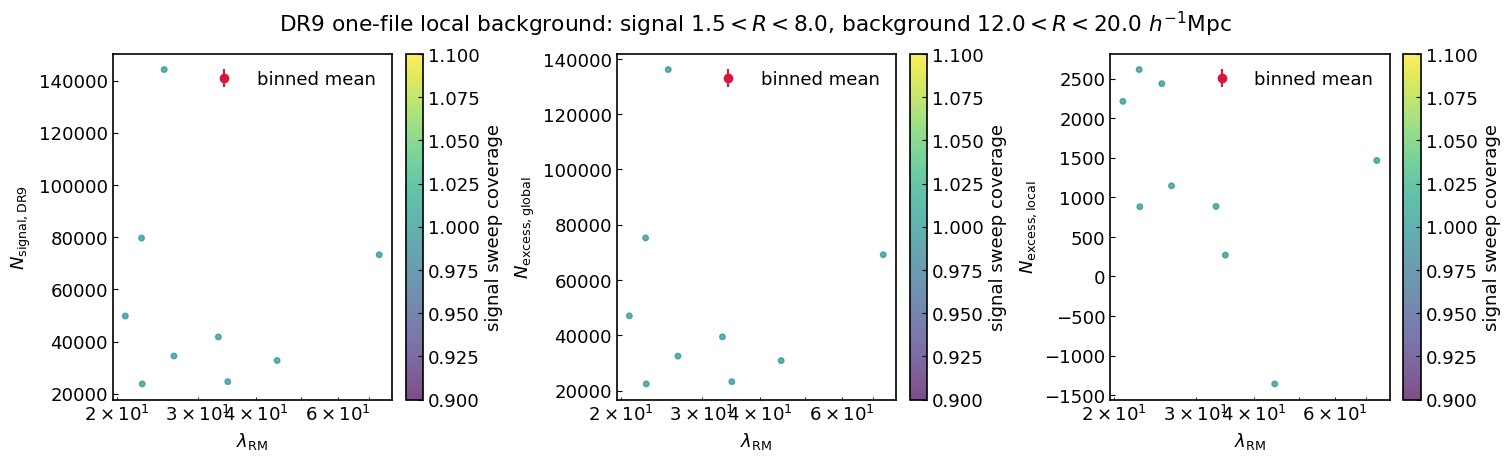

In [15]:
def add_binned_mean(ax, x, y, nbins=8, label='binned mean'):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]
    if len(x) < nbins:
        return
    bins = np.logspace(np.log10(np.nanmin(x)), np.log10(np.nanmax(x)), nbins + 1)
    centers = np.sqrt(bins[:-1] * bins[1:])
    mean, _, _ = binned_statistic(x, y, statistic='mean', bins=bins)
    std, _, _ = binned_statistic(x, y, statistic='std', bins=bins)
    count, _, _ = binned_statistic(x, y, statistic='count', bins=bins)
    good = count > 3
    sem = std / np.sqrt(np.clip(count, 1, None))
    ax.errorbar(centers[good], mean[good], yerr=sem[good], fmt='o', color='crimson', capsize=3, label=label)


x = np.asarray(rm_filt['LAMBDA'], dtype=float)
coverage_plot = np.asarray(rm_filt['coverage_signal_sweep'], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

plot_items = [
    ('Ngal_signal_DR9_annulus', r'$N_{\rm signal,DR9}$'),
    ('Nexcess_global_DR9_annulus', r'$N_{\rm excess,global}$'),
    ('Nexcess_local_DR9_annulus', r'$N_{\rm excess,local}$'),
]

for ax, (col, ylabel) in zip(axes, plot_items):
    y = np.asarray(rm_filt[col], dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(coverage_plot)
    sc = ax.scatter(x[mask], y[mask], c=coverage_plot[mask], s=16, alpha=0.7)
    add_binned_mean(ax, x[mask], y[mask])
    ax.set_xscale('log')
    ax.set_xlabel(r'$\lambda_{\rm RM}$')
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('signal sweep coverage')

fig.suptitle(fr'DR9 one-file local background: signal ${RMIN_HMPC}<R<{RMAX_HMPC}$, background ${BG_RMIN_HMPC}<R<{BG_RMAX_HMPC}\ h^{{-1}}\mathrm{{Mpc}}$')
fig.savefig(OUTPUT_DIR / 'dr9_one_file_local_background_richness_relation.png', dpi=180)
plt.show()

## Full sweep-file accumulation

This is the RAM-safe version of the one-file calculation. It reads one DR9 sweep file at a time, counts that file's contribution to the signal and background annuli, adds the counts to running totals, accumulates the sweep-file coverage area, then deletes the table before moving to the next file.

In [16]:
def find_sweep_files(sweep_dir=SWEEP_DIR, pattern=SWEEP_PATTERN, max_files=MAX_SWEEP_FILES):
    files = sorted(glob(str(Path(sweep_dir) / pattern)))
    if max_files is not None:
        files = files[:max_files]
    if len(files) == 0:
        raise FileNotFoundError(f'No sweep files matched {Path(sweep_dir) / pattern}')
    return [Path(f) for f in files]


def annulus_area_for_clusters(z_cl, Rmin_hMpc, Rmax_hMpc):
    z_cl = np.asarray(z_cl, dtype=float)
    area_sr = np.full(len(z_cl), np.nan, dtype=float)
    for i, z in enumerate(z_cl):
        if not np.isfinite(z) or z <= 0:
            continue
        th_min, th_max = annulus_theta_radians(z, Rmin_hMpc=Rmin_hMpc, Rmax_hMpc=Rmax_hMpc)
        area_sr[i] = spherical_annulus_area_sr(th_min, th_max)
    return area_sr, area_sr * (180.0 / np.pi) ** 2


def clusters_overlapping_sweep_box(ra_cl, dec_cl, z_cl, sweep_bounds, Rmax_hMpc):
    """Fast prefilter for clusters whose annulus could overlap the sweep box."""

    ra_cl = np.asarray(ra_cl, dtype=float)
    dec_cl = np.asarray(dec_cl, dtype=float)
    z_cl = np.asarray(z_cl, dtype=float)
    theta_max_deg = np.full(len(z_cl), np.nan, dtype=float)

    finite_z = np.isfinite(z_cl) & (z_cl > 0)
    theta_max_deg[finite_z] = [
        np.rad2deg(annulus_theta_radians(z, Rmax_hMpc=Rmax_hMpc)[1])
        for z in z_cl[finite_z]
    ]

    cos_dec = np.cos(np.deg2rad(dec_cl))
    ra_pad = theta_max_deg / np.clip(cos_dec, 0.2, None)
    dec_pad = theta_max_deg

    return (
        finite_z
        & (ra_cl >= sweep_bounds['ra_min'] - ra_pad)
        & (ra_cl <= sweep_bounds['ra_max'] + ra_pad)
        & (dec_cl >= sweep_bounds['dec_min'] - dec_pad)
        & (dec_cl <= sweep_bounds['dec_max'] + dec_pad)
    )


In [17]:
sweep_files = find_sweep_files()
print(f'Found {len(sweep_files):,} sweep files')
print('First file:', sweep_files[0])
print('Last file:', sweep_files[-1])

n_cl = len(rm_tab)
ra_cl = np.asarray(rm_tab['RA_x'], dtype=float)
dec_cl = np.asarray(rm_tab['DEC_x'], dtype=float)
z_cl = np.asarray(rm_tab['Z_SPEC_x'], dtype=float)

area_signal_sr_all, area_signal_deg2_all = annulus_area_for_clusters(z_cl, RMIN_HMPC, RMAX_HMPC)
area_bg_sr_all, area_bg_deg2_all = annulus_area_for_clusters(z_cl, BG_RMIN_HMPC, BG_RMAX_HMPC)

Ngal_signal_all = np.zeros(n_cl, dtype=np.int64)
Ngal_bg_all = np.zeros(n_cl, dtype=np.int64)
covered_area_signal_deg2 = np.zeros(n_cl, dtype=float)
covered_area_bg_deg2 = np.zeros(n_cl, dtype=float)
n_files_touching_cluster = np.zeros(n_cl, dtype=np.int16)

for i_file, sweep_file in enumerate(sweep_files, start=1):
    print(f'\n[{i_file}/{len(sweep_files)}] {sweep_file.name}')

    sweep_bounds_i = read_sweep_bounds(sweep_file)
    overlap = clusters_overlapping_sweep_box(
        ra_cl,
        dec_cl,
        z_cl,
        sweep_bounds_i,
        Rmax_hMpc=BG_RMAX_HMPC,
    )
    idx = np.where(overlap)[0]
    print(f'  clusters with possible overlap: {len(idx):,}')

    if len(idx) == 0:
        continue

    dr9_i = read_one_dr9_sweep(sweep_file, r_mag_limit=R_MAG_LIMIT)
    print(f'  selected galaxies: {len(dr9_i):,}')

    Nsig_i, _ = count_galaxies_in_annuli(
        ra_cl[idx],
        dec_cl[idx],
        z_cl[idx],
        dr9_i['RA'],
        dr9_i['DEC'],
        Rmin_hMpc=RMIN_HMPC,
        Rmax_hMpc=RMAX_HMPC,
        nside=NSIDE_GAL,
        verbose_every=0,
    )
    Nbg_i, _ = count_galaxies_in_annuli(
        ra_cl[idx],
        dec_cl[idx],
        z_cl[idx],
        dr9_i['RA'],
        dr9_i['DEC'],
        Rmin_hMpc=BG_RMIN_HMPC,
        Rmax_hMpc=BG_RMAX_HMPC,
        nside=NSIDE_GAL,
        verbose_every=0,
    )

    cov_sig_i, _ = sweep_annulus_coverage_for_clusters(
        ra_cl[idx],
        dec_cl[idx],
        z_cl[idx],
        sweep_bounds_i,
        Rmin_hMpc=RMIN_HMPC,
        Rmax_hMpc=RMAX_HMPC,
        nside=NSIDE_SWEEP_COVERAGE,
        verbose_every=0,
    )
    cov_bg_i, _ = sweep_annulus_coverage_for_clusters(
        ra_cl[idx],
        dec_cl[idx],
        z_cl[idx],
        sweep_bounds_i,
        Rmin_hMpc=BG_RMIN_HMPC,
        Rmax_hMpc=BG_RMAX_HMPC,
        nside=NSIDE_SWEEP_COVERAGE,
        verbose_every=0,
    )

    Ngal_signal_all[idx] += Nsig_i
    Ngal_bg_all[idx] += Nbg_i
    covered_area_signal_deg2[idx] += np.nan_to_num(cov_sig_i, nan=0.0) * area_signal_deg2_all[idx]
    covered_area_bg_deg2[idx] += np.nan_to_num(cov_bg_i, nan=0.0) * area_bg_deg2_all[idx]
    n_files_touching_cluster[idx] += 1

    del dr9_i, Nsig_i, Nbg_i, cov_sig_i, cov_bg_i
    gc.collect()

    if SAVE_EVERY_N_FILES and (i_file % SAVE_EVERY_N_FILES == 0):
        print('  saving checkpoint')
        checkpoint = Table()
        checkpoint['ID'] = rm_tab['ID']
        checkpoint['Ngal_signal_DR9_annulus'] = Ngal_signal_all
        checkpoint['Ngal_bg_DR9_annulus'] = Ngal_bg_all
        checkpoint['covered_area_signal_deg2'] = covered_area_signal_deg2
        checkpoint['covered_area_bg_deg2'] = covered_area_bg_deg2
        checkpoint['n_files_touching_cluster'] = n_files_touching_cluster
        checkpoint.write(OUTPUT_DIR / 'dr9_all_sweeps_running_checkpoint.ecsv', format='ascii.ecsv', overwrite=True)

print('\nFinished all sweep files')


Found 283 sweep files
First file: /global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/sweep/9.0/sweep-000m005-010p000.fits
Last file: /global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/sweep/9.0/sweep-350p030-360p035.fits

[1/283] sweep-000m005-010p000.fits
  clusters with possible overlap: 63
  selected galaxies: 0

[2/283] sweep-000p000-010p005.fits
  clusters with possible overlap: 86
  selected galaxies: 0

[3/283] sweep-010m005-020p000.fits
  clusters with possible overlap: 23
  selected galaxies: 0

[4/283] sweep-010p000-020p005.fits
  clusters with possible overlap: 33
  selected galaxies: 0

[5/283] sweep-010p025-020p030.fits
  clusters with possible overlap: 0

[6/283] sweep-010p030-020p035.fits
  clusters with possible overlap: 0

[7/283] sweep-020p025-030p030.fits
  clusters with possible overlap: 0

[8/283] sweep-030m005-040p000.fits
  clusters with possible overlap: 66
  selected galaxies: 281,867

[9/283] sweep-030p000-040p005.fits
  clusters with possible overlap: 68
  

In [20]:
coverage_signal_all = covered_area_signal_deg2 / area_signal_deg2_all
coverage_bg_all = covered_area_bg_deg2 / area_bg_deg2_all

# If neighboring sweep boxes overlap, coverage can slightly exceed one. Keep the
# raw accumulated value for debugging, but use a clipped value for cuts/plots.
coverage_signal_clipped = np.clip(coverage_signal_all, 0.0, 1.0)
coverage_bg_clipped = np.clip(coverage_bg_all, 0.0, 1.0)

Sigma_signal_all = Ngal_signal_all / covered_area_signal_deg2
Sigma_bg_all = Ngal_bg_all / covered_area_bg_deg2
Sigma_excess_local_all = Sigma_signal_all - Sigma_bg_all
Nexcess_local_all = Sigma_excess_local_all * area_signal_deg2_all

# Attach the new DR9 local-overdensity columns directly to a copy of the
# redMaPPer cluster table.  This is the final cluster table to use downstream.
rm_tab_dr9 = rm_tab.copy()
rm_tab_dr9['Ngal_signal_DR9_annulus'] = Ngal_signal_all
rm_tab_dr9['Ngal_bg_DR9_annulus'] = Ngal_bg_all
rm_tab_dr9['area_signal_deg2'] = area_signal_deg2_all
rm_tab_dr9['area_bg_deg2'] = area_bg_deg2_all
rm_tab_dr9['covered_area_signal_deg2'] = covered_area_signal_deg2
rm_tab_dr9['covered_area_bg_deg2'] = covered_area_bg_deg2
rm_tab_dr9['coverage_signal_sweep'] = coverage_signal_clipped
rm_tab_dr9['coverage_bg_sweep'] = coverage_bg_clipped
rm_tab_dr9['coverage_signal_sweep_raw'] = coverage_signal_all
rm_tab_dr9['coverage_bg_sweep_raw'] = coverage_bg_all
rm_tab_dr9['n_files_touching_cluster'] = n_files_touching_cluster
rm_tab_dr9['Sigma_signal_covcorr'] = Sigma_signal_all
rm_tab_dr9['Sigma_bg_covcorr'] = Sigma_bg_all
rm_tab_dr9['Sigma_excess_local_DR9_annulus'] = Sigma_excess_local_all
rm_tab_dr9['Nexcess_local_DR9_annulus'] = Nexcess_local_all

# Keep the older variable name as an alias so downstream cells still work.
rm_all_sweeps = rm_tab_dr9

full_mask = (
    (np.asarray(rm_all_sweeps['coverage_signal_sweep'], dtype=float) > COVERAGE_MIN)
    & (np.asarray(rm_all_sweeps['coverage_bg_sweep'], dtype=float) > COVERAGE_MIN)
    & np.isfinite(rm_all_sweeps['Nexcess_local_DR9_annulus'])
    & np.isfinite(rm_all_sweeps['Sigma_excess_local_DR9_annulus'])
)
rm_all_sweeps_filt = rm_all_sweeps[full_mask]

print(f'All-sweep coverage cut: signal and background sweep coverage > {COVERAGE_MIN}')
print(f'Kept {len(rm_all_sweeps_filt):,}/{len(rm_all_sweeps):,} clusters')
print(f"Clusters with Ngal_signal > 0 before coverage cut: {np.count_nonzero(np.asarray(rm_all_sweeps['Ngal_signal_DR9_annulus']) > 0):,}")
print(f"Clusters with Ngal_signal > 0 after coverage cut: {np.count_nonzero(np.asarray(rm_all_sweeps_filt['Ngal_signal_DR9_annulus']) > 0):,}")

if np.nanmax(coverage_signal_all) > 1.05 or np.nanmax(coverage_bg_all) > 1.05:
    print('Warning: some accumulated sweep coverages exceed 1.05; check for overlapping sweep files or duplicated regions.')

# Save the redMaPPer cluster table with the new DR9 local-overdensity columns.
rm_tab_dr9.write(OUTPUT_DIR / 'rm_dr9_local_overdensity_sweep.ecsv', format='ascii.ecsv', overwrite=True)
rm_tab_dr9.write(OUTPUT_DIR / 'rm_dr9_local_overdensity_sweep.fits', overwrite=True)
rm_all_sweeps_filt.write(OUTPUT_DIR / 'rm_dr9_local_overdensity_sweep_coverage_cut.ecsv', format='ascii.ecsv', overwrite=True)
rm_all_sweeps_filt.write(OUTPUT_DIR / 'rm_dr9_local_overdensity_sweep_coverage_cut.fits', overwrite=True)

# Backward-compatible names from the first draft of this notebook.
rm_tab_dr9.write(OUTPUT_DIR / 'dr9_all_sweeps_cluster_counts.ecsv', format='ascii.ecsv', overwrite=True)
rm_all_sweeps_filt.write(OUTPUT_DIR / 'dr9_all_sweeps_cluster_counts_coverage_cut.ecsv', format='ascii.ecsv', overwrite=True)

print('Saved redMaPPer table with DR9 local-overdensity columns to:')
print(' ', OUTPUT_DIR / 'rm_dr9_local_overdensity_sweep.ecsv')
print(' ', OUTPUT_DIR / 'rm_dr9_local_overdensity_sweep.fits')
print(' ', OUTPUT_DIR / 'rm_dr9_local_overdensity_sweep_coverage_cut.ecsv')
print(' ', OUTPUT_DIR / 'rm_dr9_local_overdensity_sweep_coverage_cut.fits')


All-sweep coverage cut: signal and background sweep coverage > 0.8
Kept 2,360/6,739 clusters
Clusters with Ngal_signal > 0 before coverage cut: 2,231
Clusters with Ngal_signal > 0 after coverage cut: 2,206
Saved redMaPPer table with DR9 local-overdensity columns to:
  dr9_one_file_outputs/rm_dr9_local_overdensity_sweep.ecsv
  dr9_one_file_outputs/rm_dr9_local_overdensity_sweep.fits
  dr9_one_file_outputs/rm_dr9_local_overdensity_sweep_coverage_cut.ecsv
  dr9_one_file_outputs/rm_dr9_local_overdensity_sweep_coverage_cut.fits


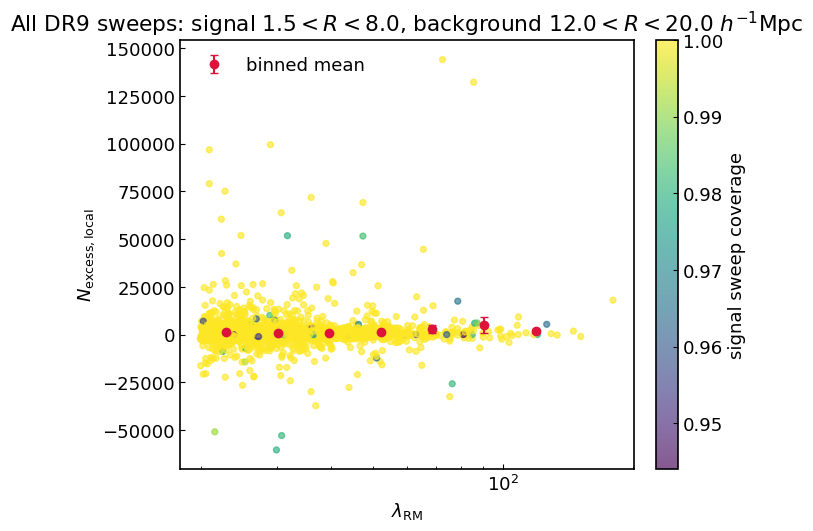


All sweeps: local-background DR9 excess count vs richness
  Pearson  r = 0.048, p = 2.020e-02
  Spearman r = 0.025, p = 2.310e-01

All sweeps: local-background DR9 excess surface density vs richness
  Pearson  r = 0.031, p = 1.285e-01
  Spearman r = 0.030, p = 1.404e-01


In [19]:
x = np.asarray(rm_all_sweeps_filt['LAMBDA'], dtype=float)
y = np.asarray(rm_all_sweeps_filt['Nexcess_local_DR9_annulus'], dtype=float)
coverage_plot = np.asarray(rm_all_sweeps_filt['coverage_signal_sweep'], dtype=float)

fig, ax = plt.subplots(figsize=(6.8, 5.2))
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(coverage_plot)
sc = ax.scatter(x[mask], y[mask], c=coverage_plot[mask], s=18, alpha=0.65)
add_binned_mean(ax, x[mask], y[mask], nbins=8, label='binned mean')
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda_{\rm RM}$')
ax.set_ylabel(r'$N_{\rm excess,local}$')
ax.set_title(fr'All DR9 sweeps: signal ${RMIN_HMPC}<R<{RMAX_HMPC}$, background ${BG_RMIN_HMPC}<R<{BG_RMAX_HMPC}\ h^{{-1}}\mathrm{{Mpc}}$')
ax.legend(frameon=False)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('signal sweep coverage')
fig.savefig(OUTPUT_DIR / 'dr9_all_sweeps_local_background_richness_relation.png', dpi=180)
plt.show()

print_correlation('All sweeps: local-background DR9 excess count vs richness', x, y)
print_correlation('All sweeps: local-background DR9 excess surface density vs richness', x, rm_all_sweeps_filt['Sigma_excess_local_DR9_annulus'])
